# GROOPY - Exploring the ASL Alphabet
### CRISP-DM: Data Understanding

Before training anything, we look at the data: **images per class**, **what the signs look like**, **image properties**, and the **hard-to-tell-apart letters**. These findings drive the preprocessing + augmentation used in `02_bakeoff.ipynb`.

> Runs on **Colab or locally** (auto-detected). Run this **before** the bake-off - it's quick and the plots are great Data-Understanding evidence for your report.

## 1 - Setup
On Colab: clones the repo + downloads the data (needs a Kaggle *legacy* `kaggle.json`; accept the [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet) terms once). Locally: just makes the repo importable (assumes the data is already downloaded).

In [5]:
import os, sys
try:
    import google.colab            # ---- running on Colab ----
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/SpliiiiT/GROOPY.git 2>/dev/null || (cd GROOPY && git pull -q)
    %cd /content/GROOPY
    sys.path.insert(0, '/content/GROOPY')
    !pip install -q kaggle
    from google.colab import files; files.upload()      # upload kaggle.json
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !python data/download_asl_alphabet.py
else:                               # ---- running locally ----
    sys.path.insert(0, os.path.abspath('../..'))   # repo root
    print('Local run - using data/asl_alphabet_train (already downloaded).')


Local run - using data/asl_alphabet_train (already downloaded).


## 2 - How many images per class?
Balanced classes mean accuracy isn't skewed. ASL Alphabet is usually ~3000 per class.

29 classes, 87,000 images, 3000-3000 per class


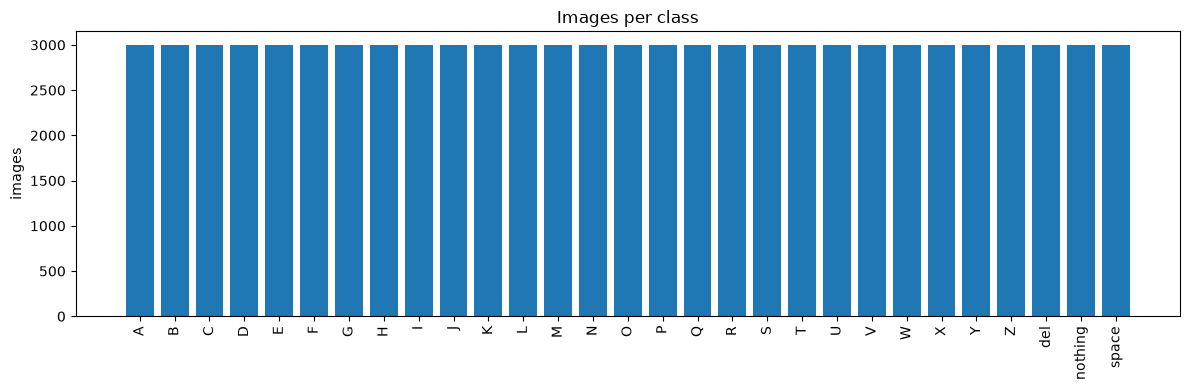

In [2]:
import os, matplotlib.pyplot as plt
from recognition.src.config import ASL_TRAIN_DIR

counts = {c: len(os.listdir(ASL_TRAIN_DIR / c)) for c in sorted(os.listdir(ASL_TRAIN_DIR))}
print(f'{len(counts)} classes, {sum(counts.values()):,} images, '
      f'{min(counts.values())}-{max(counts.values())} per class')

plt.figure(figsize=(12, 4)); plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90); plt.ylabel('images'); plt.title('Images per class')
plt.tight_layout(); plt.show()

## 3 - What do the signs look like?
One example per class - check labels match handshapes and get a feel for lighting/background variation.

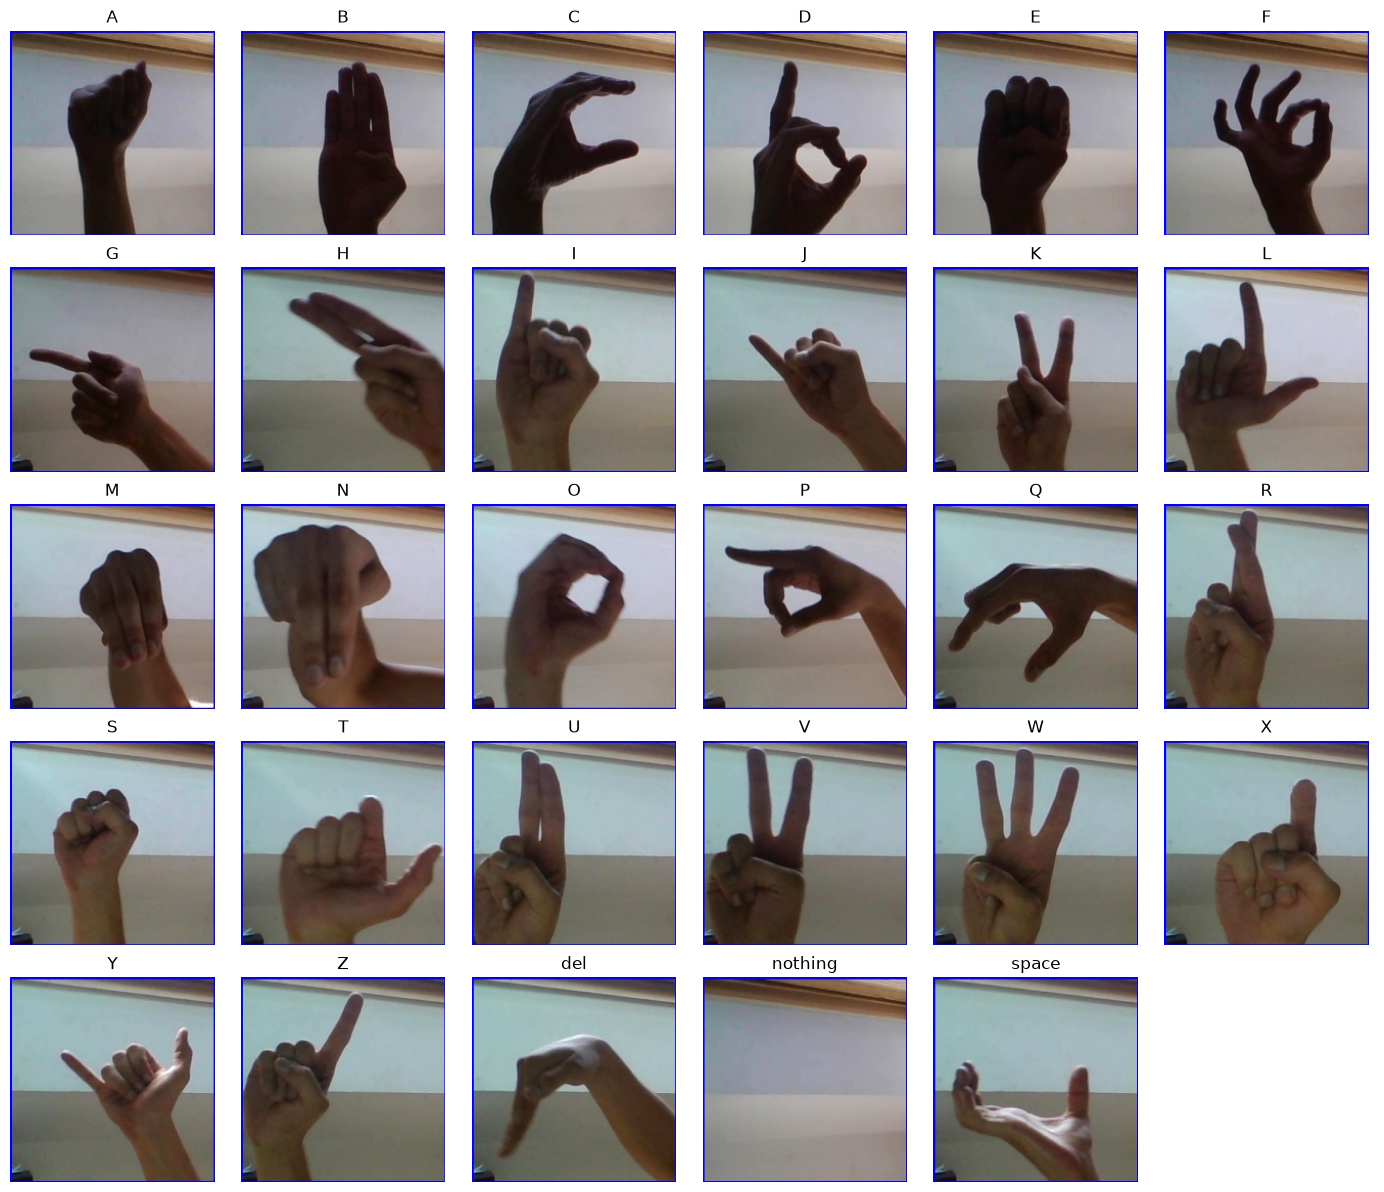

In [3]:
import cv2
classes = sorted(counts)
fig, axes = plt.subplots(5, 6, figsize=(14, 12))
for ax, cls in zip(axes.ravel(), classes):
    p = next((ASL_TRAIN_DIR / cls).glob('*'))
    ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
    ax.set_title(cls); ax.axis('off')
for ax in axes.ravel()[len(classes):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4 - Image properties
Confirm a consistent size/format so we can resize uniformly to 224x224.

In [4]:
shapes = {cv2.imread(str(next((ASL_TRAIN_DIR / c).glob('*')))).shape for c in classes[:10]}
print('sample image shapes (H, W, C):', shapes)

sample image shapes (H, W, C): {(200, 200, 3)}


## 5 - Takeaways -> Data Preparation

- **Balanced classes** -> accuracy is fair (we still report macro-F1).
- **Consistent size** -> resize to **224x224** (pretrained backbones expect it).
- **No horizontal flip** in augmentation - it changes some handshapes into different letters.
- **Hard pairs** (M/N/S/T, A/E) look alike -> expect confusion; we check it in `02_bakeoff.ipynb`.
- **Background/lighting varies** -> crop to the hand before classifying (`preprocess.py`).

Next: **`02_bakeoff.ipynb`**.